이 내용은 주피터 노트북(`ipynb`)의 **Markdown 셀**과 **Code 셀**에 각각 복사하여 붙여넣을 수 있도록 최적화된 강의 자료 형식입니다.

---

# Lecture 1: Foundations and Gradient Dynamics

### **Recommended Readings**
* [CS231n: Recurrent Neural Networks](https://cs231n.github.io/rnn/)
* [Understanding LSTM Networks (colah's blog)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)

---

## 1. Introduction to Sequential Data

### **Limitations of Vanilla Neural Networks**
Traditional neural networks (and Convolutional Networks) have a major limitation: They accept a fixed-sized vector as input (e.g., an image) and produce a fixed-sized vector as output (e.g., probabilities of different classes). Furthermore, these models perform this mapping with a fixed number of computational steps (e.g., the number of layers in the model).

### **The Need for RNNs**
Recurrent Neural Networks are unique because they allow us to operate over **sequences** of vectors: Sequences in the input, the output, or in the most general case both.

### **Generating Synthetic Periodic Data (Sine Wave)**
To illustrate these concepts, we first generate a simple sine wave which will serve as our sequential data.

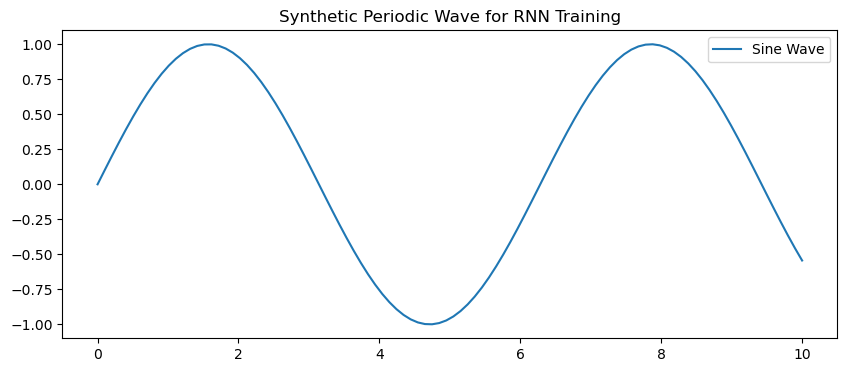

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_periodic_wave(steps=100):
    t = np.linspace(0, 10, steps)
    data = np.sin(t)
    return t, data

t, wave = generate_periodic_wave()
plt.figure(figsize=(10, 4))
plt.plot(t, wave, label='Sine Wave')
plt.title("Synthetic Periodic Wave for RNN Training")
plt.legend()
plt.show()


## 2. Recurrent Neural Network (RNN) Core

### **The Recurrence Formula**
The core of an RNN is a state $h_t$ (hidden vector) that is updated at every time step $t$ by applying a recurrence formula:

$h_t = f_W(h_{t-1}, x_t)$

Specifically, a vanilla RNN uses the following equation:
$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$

* $h_{t-1}$: Hidden state from the previous time step (memory).
* $x_t$: Input vector at the current time step.
* $W_{hh}, W_{xh}$: Weight matrices (parameters) that are **shared across all time steps**.

### **Computational Graph: Unrolling through Time**
An RNN can be thought of as multiple copies of the same network, each passing a message to a successor. This "unrolling" allows the network to process sequences.

---

## 3. Sequential Paradigms & Code Examples

Below are the different architectural variations of RNNs based on the input-output mapping.

### **3.1 One-to-One**
Standard "Vanilla" NN mapping a fixed-sized input to a fixed-sized output.
* **Example:** Predicting a single future value $y$ from a single current value $x$.

```python
# Conceptual mapping: x -> [RNN Cell] -> y
x_input = wave[0]
# y_pred = model(x_input)
```

### **3.2 One-to-Many**
A single input maps to a sequence of outputs.
* **Example:** Image Captioning (Image -> Sequence of words) or generating a wave sequence from a single seed.

```python
seed = wave[0]
generated_wave = []
h = np.zeros((1, 10)) # initial hidden state

for i in range(20):
    # h = tanh(W_hh * h + W_xh * seed)
    # out = W_hy * h
    # generated_wave.append(out)
    # seed = out (feeding the output back as next input)
    pass
```

### **3.3 Many-to-One**
A sequence of inputs maps to a single output.
* **Example:** Sentiment Analysis or predicting the next single value from a history of values.

```python
input_sequence = wave[0:10]
h = np.zeros((1, 10))

for x_t in input_sequence:
    # h = tanh(W_hh * h + W_xh * x_t)
    pass

# final_prediction = W_hy * h
```

### **3.4 Many-to-Many**
Input and output are both sequences.
* **Example:** Part-of-speech tagging (each $x_t$ has a corresponding $y_t$).

```python
input_sequence = wave[0:10]
outputs = []
h = np.zeros((1, 10))

for x_t in input_sequence:
    # h = tanh(W_hh * h + W_xh * x_t)
    # y_t = W_hy * h
    # outputs.append(y_t)
    pass
```

### **3.5 Seq2Seq (Sequence-to-Sequence)**
A special type of many-to-many where the output starts only after the entire input sequence has been processed. This uses an **Encoder-Decoder** architecture.
* **Example:** Machine Translation or multi-step time-series forecasting.

```python
# 1. Encoder Phase
input_seq = wave[0:10]
h_enc = np.zeros((1, 10))
for x_t in input_seq:
    # h_enc = encoder_step(x_t, h_enc)
    pass

# 2. Decoder Phase (Seq2Seq)
h_dec = h_enc # Transfer hidden state (Context Vector)
current_input = input_seq[-1]
predictions = []
for i in range(10):
    # h_dec, out = decoder_step(current_input, h_dec)
    # predictions.append(out)
    # current_input = out
    pass
```

주피터 노트북의 Markdown 셀에 복사하여 붙여넣을 수 있는 강의 1의 후반부 구성안입니다. CS231n의 핵심 분석 내용을 포함하되, 학술적 관점에서 재구성하였습니다.

---

## 3. Training RNNs

### **Backpropagation Through Time (BPTT)**
RNN의 학습은 일반적인 역전파(Backpropagation)의 확장판인 BPTT를 통해 이루어집니다. 
- **The Concept**: 전개된(Unrolled) 그래프 상에서 모든 시간 단계(Time step)에 대해 그래디언트를 계산합니다.
- **Shared Parameters**: 동일한 가중치 $W_{hh}, W_{xh}$가 모든 시점에 사용되므로, 각 시점에서 계산된 그래디언트들의 합(Summation)을 통해 최종 업데이트가 결정됩니다.
- **Chain Rule**: 손실 함수 $L$에 대한 가중치의 미분은 시간을 거슬러 올라가며 연쇄 법칙을 적용합니다.

### **Truncated BPTT**
실제 매우 긴 시퀀스(예: 수천 개의 시계열 데이터)를 학습할 때, 전체 시퀀스를 한 번에 역전파하는 것은 메모리 비용이 크고 그래디언트 업데이트가 매우 느려집니다.
- **Practical Solution**: 시퀀스를 일정 구간(Chunk)으로 나누어 해당 구간 내에서만 역전파를 수행하고, 마지막 숨겨진 상태(Hidden state)만 다음 구간으로 전달하여 '상태 유지'를 지속합니다.

---

## 4. Gradient Dynamics and Stability

### **Vanishing & Exploding Gradients**
RNN 학습이 어려운 근본적인 원인은 수학적 구조에 있습니다. 시간 $t$에서의 손실에 대한 시간 $k$에서의 상태 미분($\frac{\partial h_t}{\partial h_k}$)을 분석하면 다음과 같습니다.

$\frac{\partial h_t}{\partial h_k} = \prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}} = \prod_{i=k+1}^{t} W_{hh}^T diag(f'(W_{hh}h_{i-1} + W_{xh}x_i))$

- **Exploding Gradients**: 가중치 행렬의 고윳값(Eigenvalues)이 1보다 크면, 행렬 곱이 반복됨에 따라 그래디언트가 기하급수적으로 커져 학습이 불가능해집니다.
- **Vanishing Gradients**: 반대로 고윳값이 1보다 작으면 그래디언트가 0에 수렴하여, 멀리 떨어진 과거의 정보가 현재의 학습에 영향을 주지 못하는 **Long-term Dependency** 문제가 발생합니다.

### **Heuristic & Mathematical Fixes**
1. **Gradient Clipping**: 그래디언트의 Norm이 특정 임계값을 넘으면 강제로 크기를 줄여 폭주(Exploding)를 막습니다.
2. **Spectral Radius**: $W_{hh}$의 고윳값을 조절하여 안정적인 전파를 유도합니다.

---

## 5. Gated Architectures (The Solution)

그래디언트 소실 문제를 아키텍처 구조로 해결한 것이 **Gated RNN**입니다.

### **LSTM (Long Short-Term Memory)**
핵심 아이디어는 **Cell State ($c_t$)**라는 "정보 고속도로"를 도입하는 것입니다.
- **Forget Gate**: 과거 정보를 얼마나 잊을지 결정.
- **Input Gate**: 현재 정보를 얼마나 저장할지 결정.
- **Output Gate**: 업데이트된 상태 중 무엇을 밖으로 출력할지 결정.
- **Advantage**: 덧셈 연산을 통해 그래디언트가 가로막히지 않고 먼 과거까지 잘 전달됩니다.

### **GRU (Gated Recurrent Unit)**
LSTM을 더 가볍게 최적화한 구조입니다.
- **Reset Gate**: 이전 상태를 얼마나 무시할지 결정.
- **Update Gate**: 이전 상태와 현재 상태를 어떤 비율로 혼합할지 결정.
- **Advantage**: 파라미터 수가 적어 학습 속도가 빠르며, 데이터가 적은 경우 LSTM보다 효율적일 수 있습니다.

---

## 6. Comprehensive Literature Summary

RNN 및 관련 심화 연구의 흐름을 정리한 문헌 리스트입니다.

| Author (Year) | Architecture / Model | Key Contributions |
| :--- | :--- | :--- |
| **Hochreiter & Schmidhuber (1997)** | **LSTM** | Gated Mechanism과 Cell State를 통한 장기 의존성 문제의 구조적 해결책 제시 |
| **Pascanu et al. (2013)** | **Gradient Dynamics** | RNN 학습 시 발생하는 그래디언트 소실 및 폭주 문제에 대한 수학적 분석과 해결책 제안 |
| **Cho et al. (2014)** | **GRU** | LSTM의 게이트를 단순화하여 효율성을 높인 구조 및 Seq2Seq의 초기 개념 정립 |
| **Sutskever et al. (2014)** | **Seq2Seq (Encoder-Decoder)** | 서로 다른 길이의 시퀀스를 입출력할 수 있는 범용적인 Encoder-Decoder 프레임워크 구축 |
| **Bahdanau et al. (2014)** | **Additive Attention** | 고정 길이 컨텍스트 벡터의 한계를 극복하기 위해 입력 시퀀스의 특정 부분에 집중하는 기법 도입 |
| **Xingjian et al. (2015)** | **ConvLSTM** | LSTM에 합성곱 연산을 결합하여 기상 레이더 등 시공간적(Spatiotemporal) 데이터 처리 가능케 함 |

---